# 3.5 协整性与相关性

> **这一节讲什么？**
> 
> 两只股票相关性高，就能做配对交易吗？**不一定**。相关性描述短期同涨同跌，而**协整性**才描述长期均衡关系。这一节揭示这个关键区别，并用 Engle-Granger 检验在实盘中找到真正可配对的资产。

## 学习目标
- 理解相关性（Correlation）与协整性（Cointegration）的本质区别
- 掌握 Engle-Granger 两步协整检验
- 学会在股票池中批量寻找协整配对（热力图可视化）
- 理解差价（Spread）和 Z-Score 在配对交易中的应用

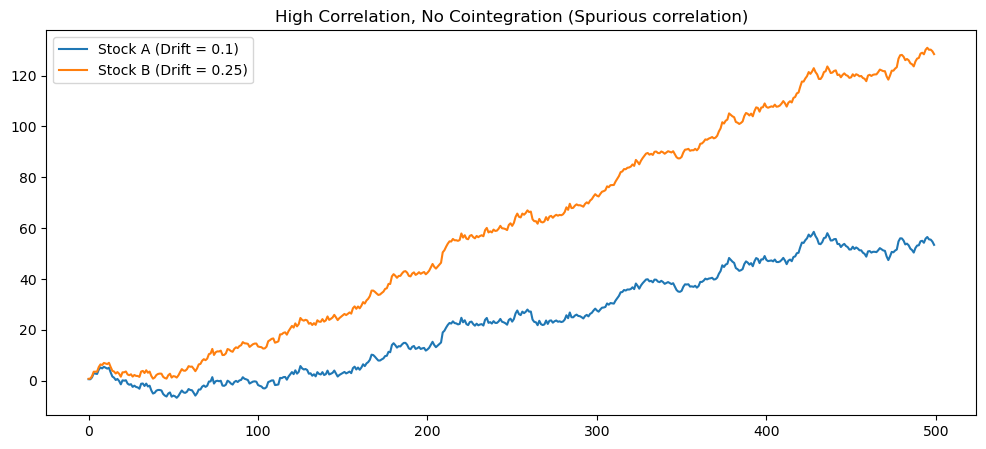

日收益率相关性: 1.0000 (极高相关性)
协整检验 p-value: 0.0771 (大于0.05，拒绝协整)


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
import matplotlib.pyplot as plt

# --- 模拟两只高度相关的股票，但它们不协整 (分别带有各自的漂移趋势) ---
np.random.seed(42)
returns_base = np.random.normal(0, 1, 500)
price_A = np.cumsum(returns_base + 0.1)  # 漂移项较小
price_B = np.cumsum(returns_base + 0.25) # 漂移项更大

plt.figure(figsize=(12, 5))
plt.plot(price_A, label='Stock A (Drift = 0.1)')
plt.plot(price_B, label='Stock B (Drift = 0.25)')
plt.title('High Correlation, No Cointegration (Spurious correlation)')
plt.legend()
plt.show()

# 它们的相关性非常高
pca_corr = np.corrcoef(np.diff(price_A), np.diff(price_B))[0, 1]
print(f'日收益率相关性: {pca_corr:.4f} (极高相关性)')

# 协整检验
_, pval_coint, _ = ts.coint(price_A, price_B)
print(f'协整检验 p-value: {pval_coint:.4f} (大于0.05，拒绝协整)')


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 4. 统计套利的基础

找到了协整关系，我们就构建了**统计套利 (Statistical Arbitrage)** 中最经典的**配对交易 (Pairs Trading)** 的基础：
1. 计算差价序列。
2. 将差价标准化为**Z-Score**。
3. 当 Z-Score > 2 时，做空差价组合（做空 Y，做多 $\beta$ 份 X）。
4. 当 Z-Score < -2 时，做多差价组合（做多 Y，做空 $\beta$ 份 X）。
5. 当差价回归均值 (Z-Score=0) 时平仓获利。

在下一章中我们会完整实现这个策略代码。


## 5. 实战：在股票池中寻找真协整资产对

现实中，量化研究员通常会圈定一个行业的股票池（比如银行股、航空股），然后在这个池子里两两计算 Engle-Granger 协整检验。找出 P-value 小于 0.05 甚至 0.01 的配对。

这往往由一个**热力图 (Heatmap)** 来实现，这是一种极其直观的可视化方法。


发现的协整配对:
Stock_B 和 Stock_E - P-value: 0.0146
Stock_C 和 Stock_D - P-value: 0.0483
Stock_C 和 Stock_E - P-value: 0.0383


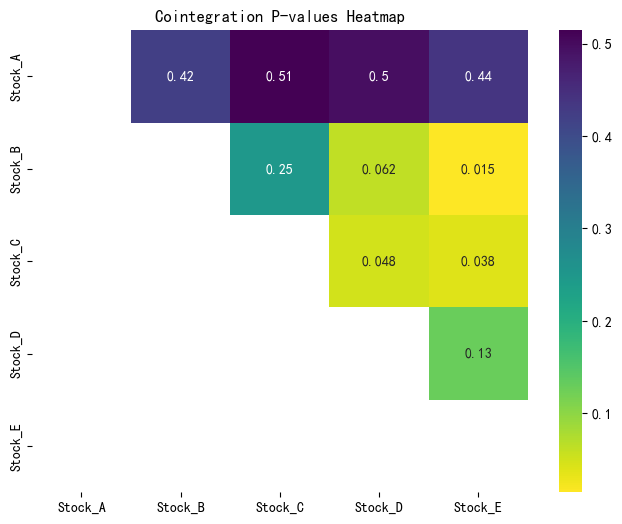

In [3]:
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.tsa.stattools as ts
import matplotlib.pyplot as plt

# --- 模拟构建一个包含 5 只股票的股票池 ---
np.random.seed(10)
returns_pool = np.random.normal(0, 1, (500, 5))
base_prices = np.cumsum(returns_pool, axis=0) + 100
pool_df = pd.DataFrame(base_prices, columns=['Stock_A', 'Stock_B', 'Stock_C', 'Stock_D', 'Stock_E'])

# 特意制造一对协整关系 (让 Stock_E 成为 Stock_B 的协整影子)
pool_df['Stock_E'] = pool_df['Stock_B'] * 1.5 - 20 + np.random.normal(0, 2, 500)

# 计算协整 P-value 矩阵
def find_cointegrated_pairs(dataframe):
    n = dataframe.shape[1]
    pvalue_matrix = np.ones((n, n))
    keys = dataframe.columns
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            S1 = dataframe[keys[i]]
            S2 = dataframe[keys[j]]
            result = ts.coint(S1, S2)
            pvalue = result[1]
            pvalue_matrix[i, j] = pvalue
            if pvalue < 0.05:
                pairs.append((keys[i], keys[j], pvalue))
    return pvalue_matrix, pairs

pvalues, cointegrated_pairs = find_cointegrated_pairs(pool_df)

print("发现的协整配对:")
for pair in cointegrated_pairs:
    print(f"{pair[0]} 和 {pair[1]} - P-value: {pair[2]:.4f}")

# 绘制热力图 P-value Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pvalues, xticklabels=pool_df.columns, yticklabels=pool_df.columns, cmap='viridis_r', 
            mask=(pvalues >= 0.99), annot=True)
plt.title('Cointegration P-values Heatmap')
plt.show()


## 🎯 练习

1. 对 A 股银行板块（例如工商银行、建设银行、农业银行）的股票做协整检验，找出配对。
2. 画出任意两只高相关股票 5 年内的价格走势图，观察它们的价差是否保持平稳或者最终发散。
3. 修改 `find_cointegrated_pairs` 函数，加入参数让用户自定义置信水平（0.05 或 0.01）。

---
**下一节** → `../04_backtesting/06_pairs_trading_strategy.ipynb`
